# Analysis and editing: feature edges, Hausdorff distance, region algebra, periodic pairs

Added in v16.23.0:

- **`feature_edges`** writes the sharp, open, non-manifold and inconsistently wound edges of a surface as a line mesh. It is the one crease test `decimate`, `decimate_volume` and `smooth` now pin nodes with.
- **`hausdorff_distance`** measures how far apart two surfaces are at their worst: the number a decimation, a remesh or a round trip is checked against.
- **`edit_regions`** unions, intersects, subtracts, renames, retags and deletes named regions.
- **`match_periodic_nodes`** pairs the nodes of two boundary regions that a translation or rotation maps onto each other.

Each is also a CLI verb, an MCP tool, and a C, Fortran, Julia, R and WebAssembly function.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')
TMP = tempfile.mkdtemp()


def to_grid(mesh):
    '''A PyVista grid of a meshio++ mesh, through a temporary .vtu.'''
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mesh)
    return pv.read(target)


def render(layers, title, view=(-1.0, -1.4, 0.8), size=(900, 560), ax=None, zoom=1.7):
    '''Render `(grid, kwargs)` layers with PyVista, or points with matplotlib when GL is unavailable.'''
    ax = ax or plt.figure(figsize=(9, 5.6)).add_subplot(111)
    try:
        pl = pv.Plotter(off_screen=True, window_size=size)
        for grid, kwargs in layers:
            pl.add_mesh(grid, **kwargs)
        pl.view_vector(view, viewup=(0, 0, 1))
        pl.reset_camera()
        pl.camera.zoom(zoom)
        ax.imshow(pl.screenshot(return_img=True))
        pl.close()
    except Exception as exc:  # pragma: no cover - head-less GL fallback
        print('PyVista render skipped:', exc)
        for grid, _ in layers:
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], s=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    return ax


EXAMPLE = os.path.join(os.path.dirname(os.getcwd()), 'example.msh')
part = mp.read(EXAMPLE)
volume = mp.Mesh(part.points, [c for c in part.cells if c.type == 'tetra'])
skin = mp.extract_surface(volume)
print('tetra:', len(volume.cells[0].data), ' skin triangles:', sum(len(c.data) for c in skin.cells))

tetra: 235014  skin triangles: 58394


## Feature edges

Each edge of the surface is classified from the faces that use it: used once it is **open**, three or more times **non-manifold**, twice by faces walking it the same way **inconsistent**, and twice by faces whose normals are more than `feature_angle` apart **sharp**. Only the two faces sharing an edge are compared, so a smooth surface that is merely coarsely tessellated has no feature edges. On a volume mesh the surface is its skin.

{'num_feature': 3708, 'num_boundary': 0, 'num_non_manifold': 0, 'num_inconsistent': 0}


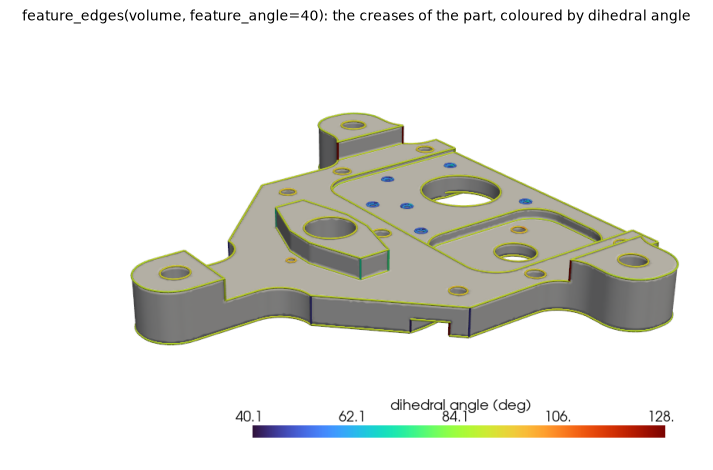

In [2]:
edges, report = mp.feature_edges(volume, feature_angle=40, return_report=True)
print(report)
render([
    (to_grid(skin), dict(color='#d9d9d9', show_edges=False, smooth_shading=True)),
    (to_grid(edges), dict(scalars='feature:angle', cmap='turbo', line_width=3, render_lines_as_tubes=True,
                          scalar_bar_args={'title': 'dihedral angle (deg)'})),
], 'feature_edges(volume, feature_angle=40): the creases of the part, coloured by dihedral angle')
plt.show()

## Decimation holds the creases, and the Hausdorff distance says by how much it moved

`decimate` pins the endpoints of every feature edge. The Hausdorff distance between the surface before and after is the largest distance from a point of either to the other — sampling the vertices gives a lower bound, `face_samples` tightens it.

face_samples=0: Hausdorff 0.001555  (before -> after 0.001555, after -> before 0.001178, mean 6.11e-05)


face_samples=2: Hausdorff 0.001555  (before -> after 0.001555, after -> before 0.001213, mean 4.43e-05)


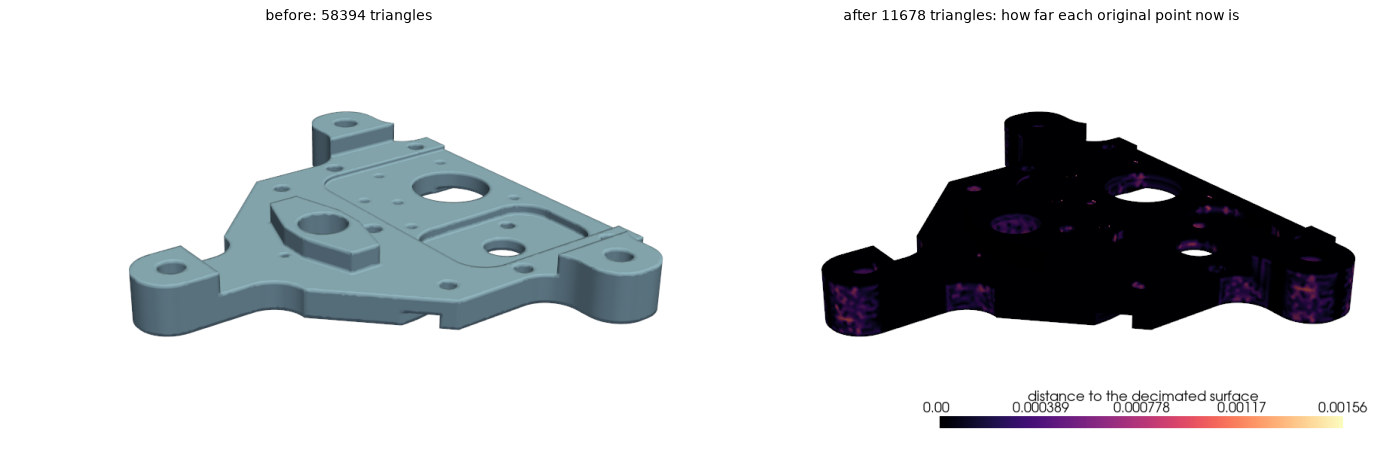

In [3]:
tri = mp.Mesh(skin.points, [c for c in skin.cells if c.type == 'triangle'])
tri = mp.clean(tri, remove_orphans=True)
coarse = mp.decimate(tri, ratio=0.2, feature_angle=40)
for s in (0, 2):
    h = mp.hausdorff_distance(tri, coarse, face_samples=s)
    print(f"face_samples={s}: Hausdorff {h['distance']:.4g}  (before -> after {h['a_to_b']:.4g}, "
          f"after -> before {h['b_to_a']:.4g}, mean {h['mean_a_to_b']:.3g})")

d = mp.distance_to_surface(tri, coarse, sign='unsigned')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
render([(to_grid(tri), dict(color='#9ecae1', smooth_shading=True))],
       f"before: {len(tri.cells[0].data)} triangles", ax=axes[0])
render([(to_grid(d), dict(scalars='sdf:distance', cmap='magma', scalar_bar_args={'title': 'distance to the decimated surface'}))],
       f"after {len(coarse.cells[0].data)} triangles: how far each original point now is", ax=axes[1])
plt.tight_layout()
plt.show()

## Region set algebra

Regions are identified by `(kind, name, dim, tag)`. `edit_regions` applies a list of edits in order to a copy of the mesh; an input must match exactly one region. Below: a plate with four named edge node sets and two overlapping cell regions, combined into the groups a boundary-condition setup wants.

bottom         point dim=-1 tag=-1 entries=13
left           point dim=-1 tag=-1 entries=13
periodic_pair  point dim=-1 tag=-1 entries=26
right          point dim=-1 tag=-1 entries=13
top            point dim=-1 tag=-1 entries=13
walls          point dim=-1 tag=-1 entries=26
Coating        cell  dim= 2 tag= 2 entries=84
hot            cell  dim= 2 tag= 1 entries=44
hot_bare       cell  dim= 2 tag= 4 entries=36
hot_coated     cell  dim= 2 tag= 3 entries=8


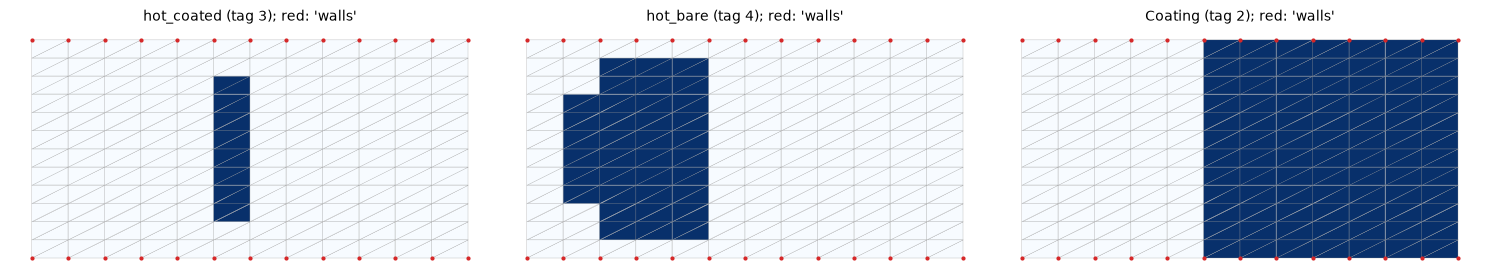

In [4]:
from meshioplusplus._regions import Region

n = 12
xs, ys = np.meshgrid(np.linspace(0, 2, n + 1), np.linspace(0, 1, n + 1))
pts = np.column_stack([xs.ravel(), ys.ravel(), np.zeros(xs.size)])
quads = np.array([[j * (n + 1) + i, j * (n + 1) + i + 1, (j + 1) * (n + 1) + i + 1, (j + 1) * (n + 1) + i]
                  for j in range(n) for i in range(n)])
plate = mp.Mesh(pts, [('quad', quads)])
ids = np.arange(len(pts))
centres = pts[quads].mean(axis=1)
plate.regions = [
    Region('left', 'point', ids[pts[:, 0] == 0.0]),
    Region('right', 'point', ids[pts[:, 0] == 2.0]),
    Region('bottom', 'point', ids[pts[:, 1] == 0.0]),
    Region('top', 'point', ids[pts[:, 1] == 1.0]),
    Region('hot', 'cell', np.nonzero(np.hypot(centres[:, 0] - 0.6, centres[:, 1] - 0.5) < 0.45)[0], dim=2, tag=1),
    Region('coated', 'cell', np.nonzero(centres[:, 0] > 0.8)[0], dim=2, tag=2),
]
edited = mp.edit_regions(plate, [
    {'op': 'union', 'inputs': ['left', 'right'], 'output': 'periodic_pair'},
    {'op': 'union', 'inputs': ['bottom', 'top'], 'output': 'walls'},
    {'op': 'intersection', 'inputs': ['hot', 'coated'], 'output': 'hot_coated', 'tag': 3},
    {'op': 'difference', 'inputs': ['hot', 'coated'], 'output': 'hot_bare', 'tag': 4},
    {'op': 'rename', 'inputs': ['coated'], 'output': 'Coating'},
])
for r in edited.regions:
    print(f'{r.name:14s} {r.kind:5s} dim={r.dim:2d} tag={r.tag:2d} entries={len(r.entries)}')

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, name in zip(axes, ['hot_coated', 'hot_bare', 'Coating']):
    r = next(r for r in edited.regions if r.name == name)
    member = np.zeros(len(quads))
    member[r.entries] = 1.0
    ax.tripcolor(pts[:, 0], pts[:, 1], np.vstack([quads[:, [0, 1, 2]], quads[:, [0, 2, 3]]]),
                 facecolors=np.concatenate([member, member]), cmap='Blues', edgecolors='#999999', linewidth=0.2)
    wall = pts[next(r for r in edited.regions if r.name == 'walls').entries]
    ax.plot(wall[:, 0], wall[:, 1], 'o', color='#d62728', ms=2)
    ax.set_title(f"{name} (tag {r.tag}); red: 'walls'", fontsize=10)
    ax.set_aspect('equal')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Periodic node pairs

A 60-degree sector of an annulus: the nodes of the cut at 0 degrees are matched onto the cut at 60 degrees by a rotation about the axis. Every slave node finds its master within `atol`; a master claimed twice, or a slave left unmatched, is an error.

[[ 0  1  2  3  4  5  6]
 [70 71 72 73 74 75 76]]
max residual: 0.0


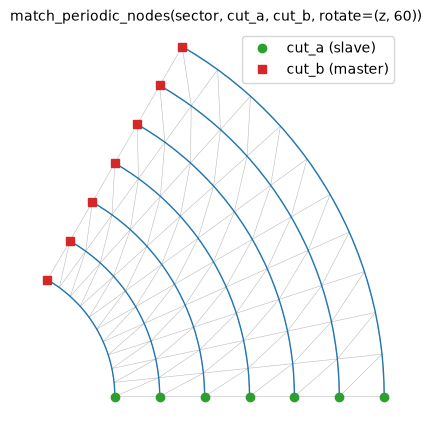

In [5]:
nr, nt = 6, 10
r = np.linspace(0.5, 1.5, nr + 1)
t = np.linspace(0.0, np.pi / 3, nt + 1)
R, T = np.meshgrid(r, t)
pts = np.column_stack([(R * np.cos(T)).ravel(), (R * np.sin(T)).ravel(), np.zeros(R.size)])
quads = np.array([[j * (nr + 1) + i, j * (nr + 1) + i + 1, (j + 1) * (nr + 1) + i + 1, (j + 1) * (nr + 1) + i]
                  for j in range(nt) for i in range(nr)])
sector = mp.Mesh(pts, [('quad', quads)])
sector.regions = [
    Region('cut_a', 'point', np.arange(nr + 1)),
    Region('cut_b', 'point', nt * (nr + 1) + np.arange(nr + 1)),
]
pairs, report = mp.match_periodic_nodes(sector, 'cut_a', 'cut_b', rotate=('z', 60.0), atol=1e-9,
                                        return_report=True)
print(pairs.T)
print('max residual:', report['max_residual'])

fig, ax = plt.subplots(figsize=(6, 5))
tris = np.vstack([quads[:, [0, 1, 2]], quads[:, [0, 2, 3]]])
ax.triplot(pts[:, 0], pts[:, 1], tris, color='#bbbbbb', lw=0.4)
for s, m in pairs:
    theta = np.linspace(0, np.pi / 3, 30)
    rad = np.hypot(*pts[s, :2])
    ax.plot(rad * np.cos(theta), rad * np.sin(theta), color='#1f77b4', lw=1)
ax.plot(*pts[pairs[:, 0], :2].T, 'o', color='#2ca02c', label='cut_a (slave)')
ax.plot(*pts[pairs[:, 1], :2].T, 's', color='#d62728', label='cut_b (master)')
ax.set_aspect('equal')
ax.legend(loc='upper right')
ax.set_title('match_periodic_nodes(sector, cut_a, cut_b, rotate=(z, 60))', fontsize=10)
ax.axis('off')
plt.show()